In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

LIGHT = "#E9E0FF"
DARK = "#caa5f1"  
DARK_SCATTER = "#5E2B97"  

DATA_PATH = Path("/Users/federico/Desktop/progetto VIS/4.2 cardiologia /05_heart_disease.csv")
df = pd.read_csv(DATA_PATH)

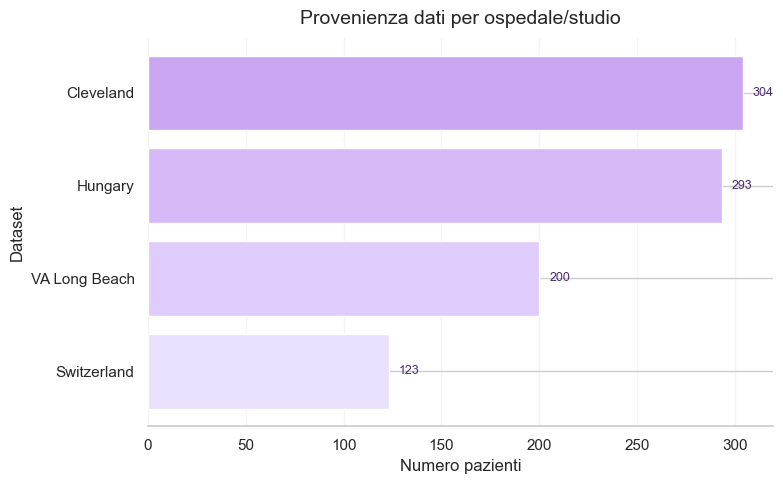

In [2]:
from matplotlib.colors import LinearSegmentedColormap

dataset_counts = df["dataset"].value_counts().sort_values()
cmap = LinearSegmentedColormap.from_list("lavender", [LIGHT, DARK])
colors = cmap(np.linspace(0, 1, len(dataset_counts)))

plt.figure(figsize=(8, 5))
plt.barh(dataset_counts.index, dataset_counts.values, color=colors)
plt.xlabel("Numero pazienti")
plt.ylabel("Dataset")
plt.title("Provenienza dati per ospedale/studio", fontsize=14, pad=10)

for i, v in enumerate(dataset_counts.values):
    plt.text(v + 5, i, f"{v:,}".replace(",", "."), va="center", fontsize=9, color="#4B2C6F")

ax = plt.gca()
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

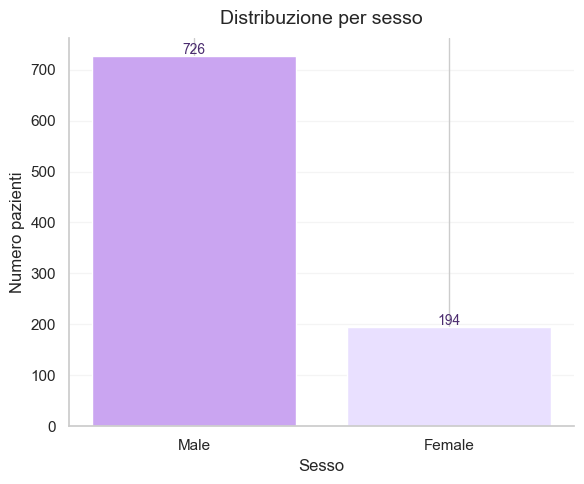

In [3]:
sex_counts = df["sex"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(sex_counts.index, sex_counts.values, color=[DARK, LIGHT], edgecolor="white")
plt.xlabel("Sesso")
plt.ylabel("Numero pazienti")
plt.title("Distribuzione per sesso", fontsize=14, pad=10)

for i, v in enumerate(sex_counts.values):
    plt.text(i, v + 5, f"{v:,}".replace(",", "."), ha="center", fontsize=10, color="#4B2C6F")

ax = plt.gca()
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

/var/folders/gk/5zl3p2k96w7gpqq6n5f6s2tr0000gn/T/ipykernel_89234/4052657400.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y="age", ax=axes[1], palette=[LIGHT, DARK])
/var/folders/gk/5zl3p2k96w7gpqq6n5f6s2tr0000gn/T/ipykernel_89234/4052657400.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Sano", "Malattia cardiaca"])


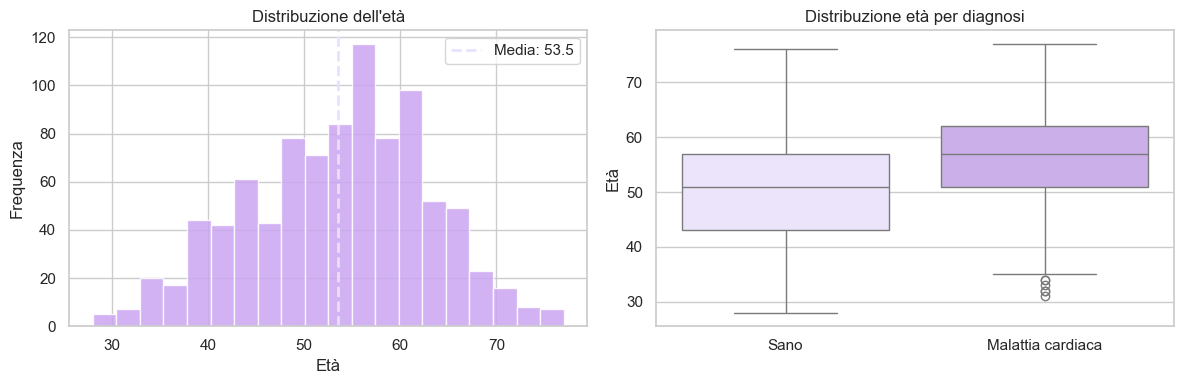

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["age"], bins=20, color=DARK, edgecolor="white", alpha=0.85)
axes[0].axvline(df["age"].mean(), color=LIGHT, linestyle="--", linewidth=2, label=f"Media: {df['age'].mean():.1f}")
axes[0].set_xlabel("Età")
axes[0].set_ylabel("Frequenza")
axes[0].set_title("Distribuzione dell'età")
axes[0].legend()

df["target"] = (df["num"] > 0).astype(int)
sns.boxplot(data=df, x="target", y="age", ax=axes[1], palette=[LIGHT, DARK])
axes[1].set_xticklabels(["Sano", "Malattia cardiaca"])
axes[1].set_xlabel("")
axes[1].set_ylabel("Età")
axes[1].set_title("Distribuzione età per diagnosi")

plt.tight_layout()
plt.show()

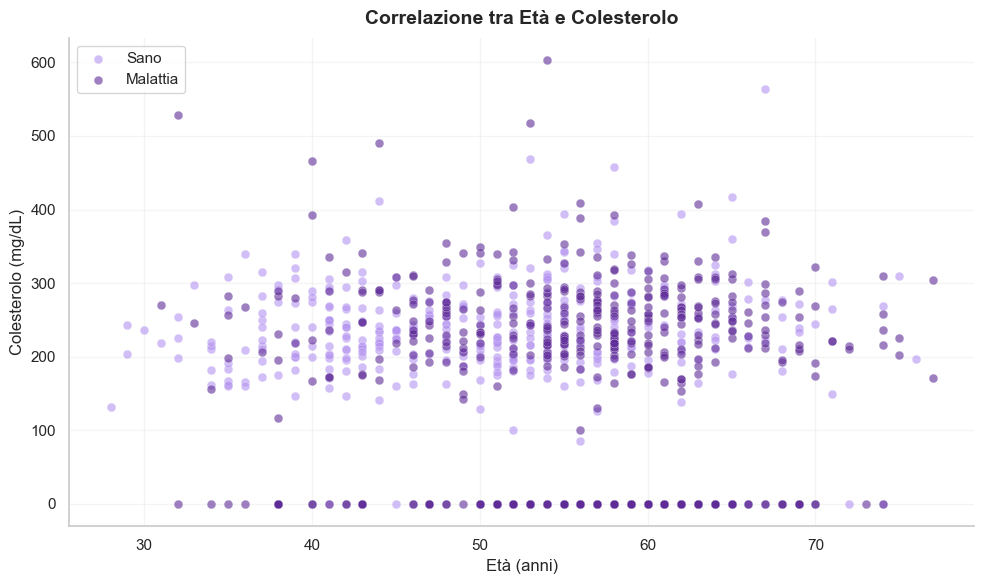

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for target_val, color, label in [(0, "#B493F0", "Sano"), (1, DARK_SCATTER, "Malattia")]:
    subset = df[df["target"] == target_val]
    ax.scatter(subset["age"], subset["chol"], c=color, alpha=0.6, s=40, label=label, edgecolor="white", linewidth=0.3)

ax.set_xlabel("Età (anni)")
ax.set_ylabel("Colesterolo (mg/dL)")
ax.set_title("Correlazione tra Età e Colesterolo", fontsize=14, fontweight="bold", pad=10)
ax.legend(loc="upper left")

for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()